Crear una imagen en RGB que contenga 4 cuadrantes en rojo, verde, azul y negro

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


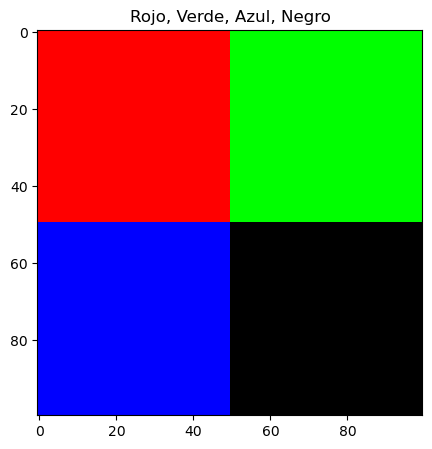

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize']=[10,5]

# Cuadrantes
size_cuadrante = 50

# Cuadrante rojo (esquina de  izquierda)
R = np.ones((size_cuadrante, size_cuadrante)) * 255
G = np.ones((size_cuadrante, size_cuadrante)) * 0
B = np.ones((size_cuadrante, size_cuadrante)) * 0
cuadrante_rojo = np.dstack((R, G, B))

#Cuadrante verde (esquina izquierda)
R = np.ones((size_cuadrante, size_cuadrante)) * 0
G = np.ones((size_cuadrante, size_cuadrante)) * 255
B = np.ones((size_cuadrante, size_cuadrante)) * 0
cuadrante_verde = np.dstack((R, G, B))

#Cuadrante azul (esquina abajo izquierda)
R = np.ones((size_cuadrante, size_cuadrante)) * 0
G = np.ones((size_cuadrante, size_cuadrante)) * 0
B = np.ones((size_cuadrante, size_cuadrante)) * 255
cuadrante_azul = np.dstack((R, G, B))

# Cuadrante negro (esquina abajo derecha)
R = np.ones((size_cuadrante, size_cuadrante)) * 0
G = np.ones((size_cuadrante, size_cuadrante)) * 0
B = np.ones((size_cuadrante, size_cuadrante)) * 0
cuadrante_negro = np.dstack((R, G, B))

size_total = size_cuadrante * 2
imagen = np.zeros((size_total, size_total, 3))

for i in range(size_cuadrante):
    for j in range(size_cuadrante):
        # parte roja (esquina arriba izquierda)
        imagen[i, j] = [255, 0, 0]
        # parte verde (esquina arriba derecha)
        imagen[i, j + size_cuadrante] = [0, 255, 0]
        # parte azul (esquina abajo izquierda)
        imagen[i + size_cuadrante, j] = [0, 0, 255]
        # parte negra (esquina abajo derecha)
        imagen[i + size_cuadrante, j + size_cuadrante] = [0, 0, 0]
imagen_completa = np.array(imagen, dtype=int)

# Mostrar
plt.figure()
plt.imshow(imagen)
plt.title('Rojo, Verde, Azul, Negro')
plt.show()

HSV a RGB

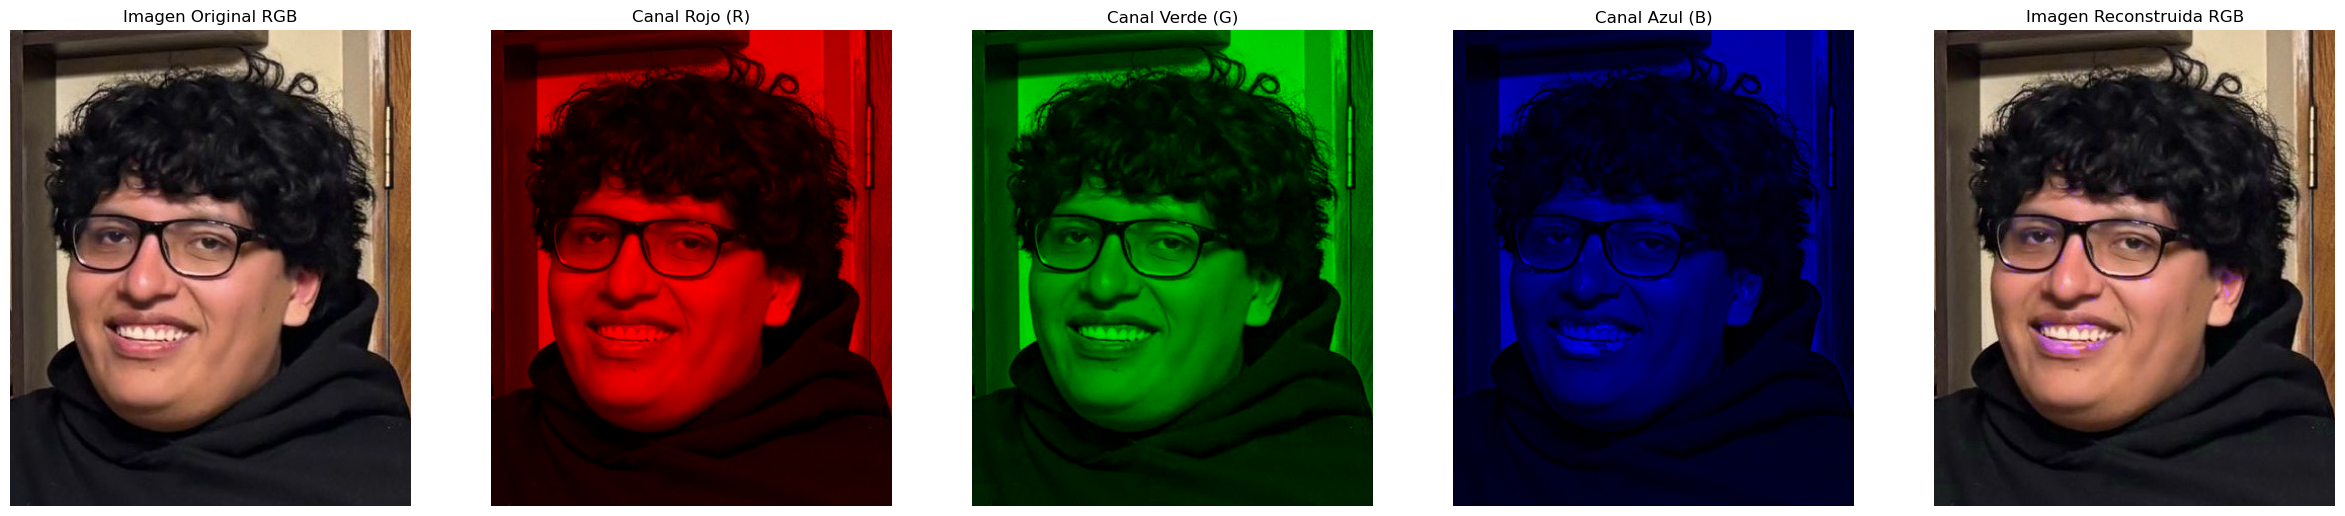

True

In [2]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np

imagen1 = cv2.imread('chanki.jpg')
img_rgb = cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)

# Funcion para convertir de RGB a HSV
def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img / 255
    nueva_img = np.zeros_like(img)

    maxChanel = np.argmax(img, axis=2)
    maxValue = np.amax(img, axis=2)
    minValue = np.amin(img, axis=2)

    nueva_img[...,2] = maxValue

    # Saturación
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j] ==0:
                nueva_img[i,j,1] = 0
            else:
                nueva_img[i,j,1] = (maxValue[i,j] - minValue[i,j]) / maxValue[i,j]
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j] == minValue[i,j]:
                nueva_img[i,j,0] = 0
            elif maxChanel[i,j] == 0:  # R
                nueva_img[i,j,0] = 60 * ((img[i,j,1] - img[i,j,2]) / (maxValue[i,j] - minValue[i,j]))
            elif maxChanel[i,j] == 1:  # G
                nueva_img[i,j,0] = 120 + 60 * ((img[i,j,2] - img[i,j,0]) / (maxValue[i,j] - minValue[i,j]))
            elif maxChanel[i,j] == 2:  # B
                nueva_img[i,j,0] = 240 + 60 * ((img[i,j,0] - img[i,j,1]) / (maxValue[i,j] - minValue[i,j]))

    # Ajuste de negativos
    nueva_img[...,0][nueva_img[...,0] < 0] += 360

    return nueva_img

# Función HSV2RGB
def HSV2RGB(hsv_img):
    nueva_img = np.zeros_like(hsv_img)
    
    for i in range(hsv_img.shape[0]):
        for j in range(hsv_img.shape[1]):
            H = hsv_img[i,j,0]
            S = hsv_img[i,j,1]
            V = hsv_img[i,j,2]
            
            if S == 0:
                nueva_img[i,j] = [V, V, V]
            else:
                # FÓRMULA 1: Convertir H a sector 0-5
                H_sector = H / 60
                sector = int(H_sector)
                H_resto = H_sector - sector
                
                # FÓRMULA 2: Calcular C y X según las fórmulas de la imagen
                # C = V * S  (color base)
                C = V * S
                # X = C * (1 - |(H/60) mod 2 - 1|)
                X = C * (1 - abs(H_resto - 1))
                # m = V - C  (luminosidad)
                m = V - C
                
                # FÓRMULA 3: Asignar RGB según el sector (tabla de conversión)
                if sector == 0:  # (0°-60°): Rojo
                    nueva_img[i,j] = [C, X, 0]
                elif sector == 1:  # (60°-120°): Amarillo
                    nueva_img[i,j] = [X, C, 0]
                elif sector == 2:  # (120°-180°): Verde
                    nueva_img[i,j] = [0, C, X]
                elif sector == 3:  # (180°-240°): Cian
                    nueva_img[i,j] = [0, X, C]
                elif sector == 4:  # (240°-300°): Azul
                    nueva_img[i,j] = [X, 0, C]
                else:  # (300°-360°): Magenta
                    nueva_img[i,j] = [C, 0, X]
                
                # FÓRMULA 4: Agregar m a cada componente y convertir a rango 0-1
                # RGB_final = [R + m, G + m, B + m]
                nueva_img[i,j,0] = nueva_img[i,j,0] + m
                nueva_img[i,j,1] = nueva_img[i,j,1] + m
                nueva_img[i,j,2] = nueva_img[i,j,2] + m
    
    return nueva_img

# Generar imagen HSV
hsv_img = RGB2HSV(img_rgb)

# Convertir de vuelta a RGB
img_rgb_resultado = HSV2RGB(hsv_img)

# Canal Rojo
canal_rojo = np.zeros_like(img_rgb_resultado)
canal_rojo[:,:,0] = img_rgb_resultado[:,:,0]

# Canal Verde
canal_verde = np.zeros_like(img_rgb_resultado)
canal_verde[:,:,1] = img_rgb_resultado[:,:,1]

# Canal Azul
canal_azul = np.zeros_like(img_rgb_resultado)
canal_azul[:,:,2] = img_rgb_resultado[:,:,2]

# Resultados
fig, axs = plt.subplots(1,5,figsize=(30,10))

axs[0].imshow(img_rgb)
axs[0].set_title('Imagen Original RGB')
axs[0].axis('off')

axs[1].imshow(canal_rojo)
axs[1].set_title('Canal Rojo (R)')
axs[1].axis('off')

axs[2].imshow(canal_verde)
axs[2].set_title('Canal Verde (G)')
axs[2].axis('off')

axs[3].imshow(canal_azul)
axs[3].set_title('Canal Azul (B)')
axs[3].axis('off')

axs[4].imshow(img_rgb_resultado)
axs[4].set_title('Imagen Reconstruida RGB')
axs[4].axis('off')

plt.show()

img_rgb_final = (img_rgb_resultado * 255).astype(np.uint8)
cv2.imwrite('imagen_reconstruida_rgb.png', cv2.cvtColor(img_rgb_final, cv2.COLOR_RGB2BGR))